# تمرین سوم - مقایسه الگوریتم‌های خوشه‌بندی

In [1]:
print("=================================================================")

In [2]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('airport-codes.csv')

features = ['latitude_deg','longitude_deg','elevation_ft']
data = df[features].dropna()

X = StandardScaler().fit_transform(data)

print("تعداد رکوردها:", len(data))


تعداد رکوردها: 49817


In [3]:

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X)

k_score = silhouette_score(X, k_labels)
print("Silhouette Score (K-Means):", k_score)


Silhouette Score (K-Means): 0.4912262374267414


In [4]:

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)
d_labels = dbscan.fit_predict(X)

mask = d_labels != -1

if len(set(d_labels[mask])) > 1:
    d_score = silhouette_score(X[mask], d_labels[mask])
else:
    d_score = -1

print("Silhouette Score (DBSCAN):", d_score)


Silhouette Score (DBSCAN): -0.143333423488265


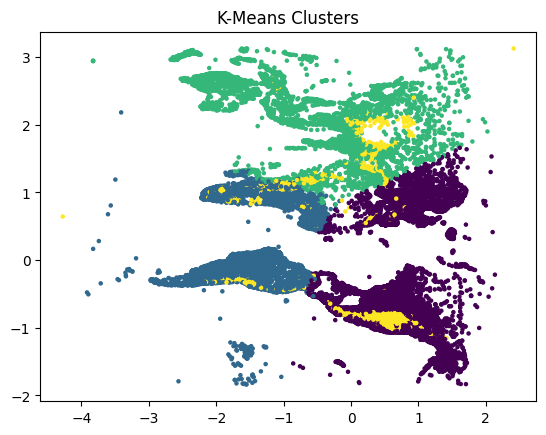

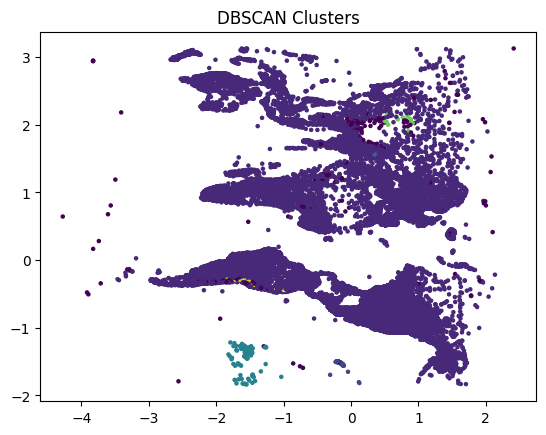

In [5]:

plt.scatter(X[:,0], X[:,1], c=k_labels, s=5)
plt.title("K-Means Clusters")
plt.show()

plt.scatter(X[:,0], X[:,1], c=d_labels, s=5)
plt.title("DBSCAN Clusters")
plt.show()


In [6]:

print("\nنتیجه نهایی")
if k_score > d_score:
    print("K-Means عملکرد بهتری داشته است.")
    print("دلیل: مقدار Silhouette Score بالاتر بوده و جداسازی خوشه‌ها بهتر انجام شده است.")
else:
    print("DBSCAN عملکرد بهتری داشته است.")
    print("دلیل: توانایی تشخیص ساختارهای متراکم و حذف نویز.")



نتیجه نهایی
K-Means عملکرد بهتری داشته است.
دلیل: مقدار Silhouette Score بالاتر بوده و جداسازی خوشه‌ها بهتر انجام شده است.
